In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from IPython.display import display

from lstm_pipeline import run_experiment
# Descargar AAPL de Yahoo Finance en el rango solicitado e incluir columnas pedidas
%pip install --quiet yfinance
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


# DATA_DIR es para incluir los sentimientos del paper FNSPID, no incluimos la carpeta por ser muy pesada. Se puede descargar desde [aca]{https://github.com/Zdong104/FNSPID_Financial_News_Dataset/tree/main/dataset_test/LSTM-for-Time-Series-Prediction/data}


In [ ]:
DATA_DIR = "/Users/mariasvidal/Desktop/LSTM-for-Time-Series-Prediction/data" 
df = pd.read_csv("dataset_para_lstm.csv")


In [3]:
# Split por ticker: un DataFrame por cada acción
# Crea un diccionario: clave = ticker, valor = DataFrame filtrado

tickers = sorted(df['ticker_individual'].dropna().unique())
dfs_por_ticker = {t: df.loc[df['ticker_individual'] == t].copy() for t in tickers}

print(f"Se generaron {len(dfs_por_ticker)} DataFrames: {tickers}")


Se generaron 15 DataFrames: ['AAPL', 'AMD', 'AMZN', 'BRK', 'DIS', 'F', 'GOOG', 'GS', 'KO', 'MSFT', 'NVDA', 'SPY', 'TSLA', 'UBER', 'WMT']


In [4]:
# Renombrar key 'BRK' -> 'BRK-B' en dfs_por_ticker (solo la key)
if 'BRK' in dfs_por_ticker:
    dfs_por_ticker['BRK-B'] = dfs_por_ticker.pop('BRK')


# Funcion para crear el dataset de un ticker

In [ ]:
# agrega el sentiment de paper si existe, sino no lo agrega
# guarda el dataframe en un csv
def create_dataset_ticker(ticker, dfs_por_ticker, save_csv=True):
    dfa = dfs_por_ticker[ticker].drop(columns=["idx"]).copy()

    dfa['Date'] = pd.to_datetime(dfa['Date'])
    dfa = dfa.sort_values('Date')
    # Sábados y domingos se computan para el lunes siguiente

    # Ajuste de fines de semana -> siguiente lunes
    wd = dfa['Date'].dt.weekday  # 0=lunes ... 5=sábado, 6=domingo
    shift_days = np.where(wd == 5, 2, np.where(wd == 6, 1, 0))
    dfa['Date_adj'] = dfa['Date'] + pd.to_timedelta(shift_days, unit='D')

    # Columnas numéricas a promediar (excluye la fecha)
    numeric_cols = dfa.select_dtypes(include='number').columns.tolist()

    # Promedios por día (usando Date_adj) y cantidad de filas originales por día
    means = dfa.groupby('Date_adj')[numeric_cols].mean().reset_index()
    counts = dfa.groupby('Date_adj').size().rename('rows_per_day').reset_index()

    df_daily = pd.merge(means, counts, on='Date_adj').rename(columns={'Date_adj': 'Date'})
    df_daily = df_daily.sort_values('Date').reset_index(drop=True)

    # descargo yahoo finance
    start_date = df_daily.Date.min()
    end_date_exclusive = df_daily.Date.max() + pd.Timedelta(days=1)
    raw = yf.download(
        ticker,
        start=start_date,
        end=end_date_exclusive,
        progress=False,
        auto_adjust=False,
        group_by='column',  # evita MultiIndex por ticker
    )
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()  # 'Date' a column

    # Descargo VIX mismo periodo
    vix = yf.download(
            "^VIX",
            start=start_date,
            end=end_date_exclusive,
            progress=False,
            auto_adjust=False,
            group_by='column',
        )
    if isinstance(vix.columns, pd.MultiIndex):
        vix.columns = vix.columns.get_level_values(0)
    vix = vix.reset_index()[["Date", "Close"]].rename(columns={"Close": "VIX"})

    raw = raw.merge(vix, on="Date", how="left")

    # junto precios con sentiment
    raw_sentiment = raw.merge(df_daily, on='Date', how='left')

    # filas de raw_sentiment que tienen nulos les asigno score 0 y creo otra columna que sea has_news=0
    raw_sentiment['has_news'] = raw_sentiment['puntaje_sent_fin_pos'].notnull().astype(int)
    raw_sentiment['puntaje_sent_fin_pos'] = raw_sentiment['puntaje_sent_fin_pos'].fillna(0)
    raw_sentiment['puntaje_sent_fin_neg'] = raw_sentiment['puntaje_sent_fin_neg'].fillna(0)
    raw_sentiment['puntaje_sent_fin_neu'] = raw_sentiment['puntaje_sent_fin_neu'].fillna(0)
    raw_sentiment['rows_per_day'] = raw_sentiment['rows_per_day'].fillna(0)
    raw_sentiment['recom_inv_llm'] = raw_sentiment['recom_inv_llm'].fillna(0)

    # agrego la columna de sentiment de paper si existe, sino no lo agrego
    try:    
        raw_sentiment_paper = pd.read_csv(f'{DATA_DIR}/{ticker}.csv')
        raw_sentiment_paper['Date'] = pd.to_datetime(raw_sentiment_paper['Date']).dt.tz_localize(None)
        raw_sentiment = raw_sentiment.merge(raw_sentiment_paper[['Date',"Sentiment_gpt", "Scaled_sentiment", "News_flag"]], on='Date', how='left')
    except:
        pass

    # guardo el dataframe en un csv
    if save_csv:
        raw_sentiment.to_csv(f'./dataset_ceci_sol/{ticker}.csv', index=False)
    return raw_sentiment

DataFrame creado para AAPL


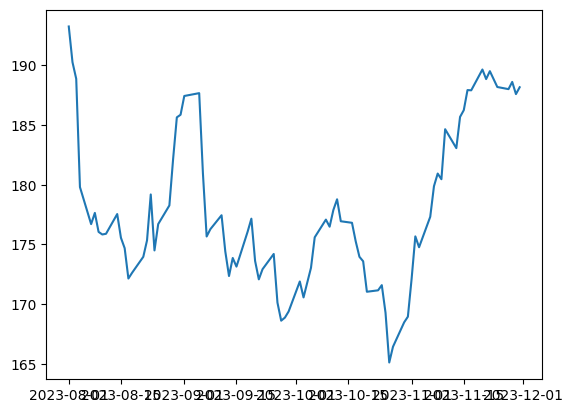

DataFrame creado para AMD


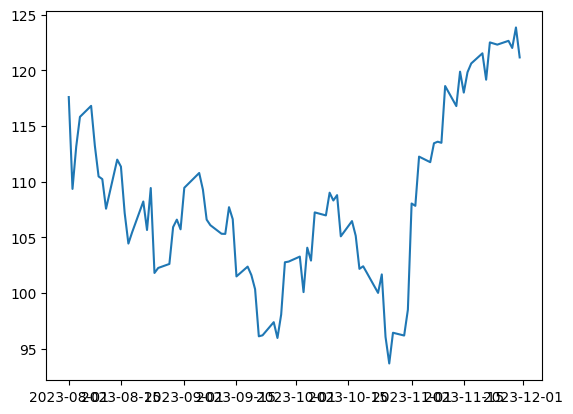

DataFrame creado para AMZN


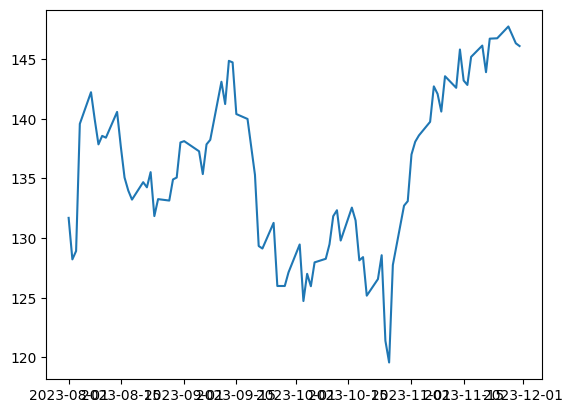

DataFrame creado para DIS


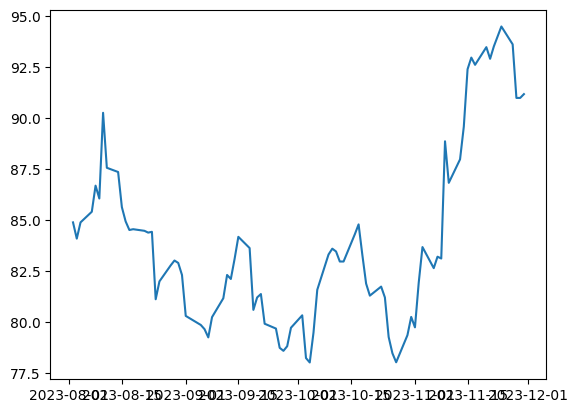

DataFrame creado para F


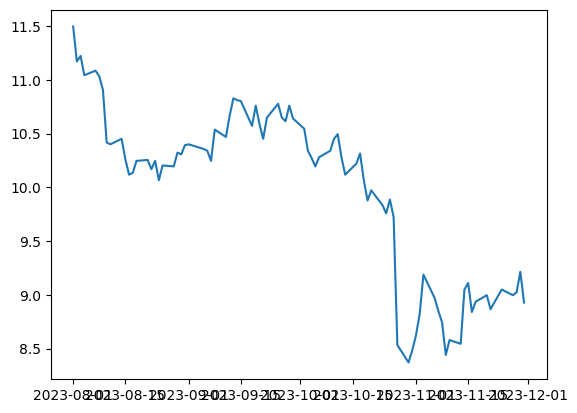

DataFrame creado para GOOG


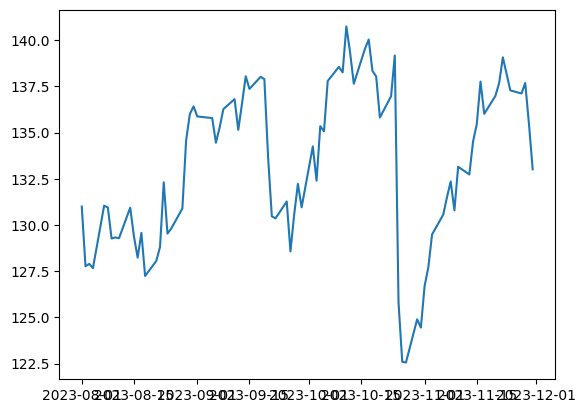

DataFrame creado para GS


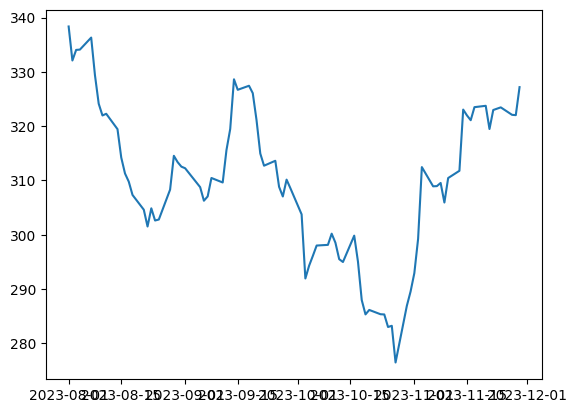

DataFrame creado para KO


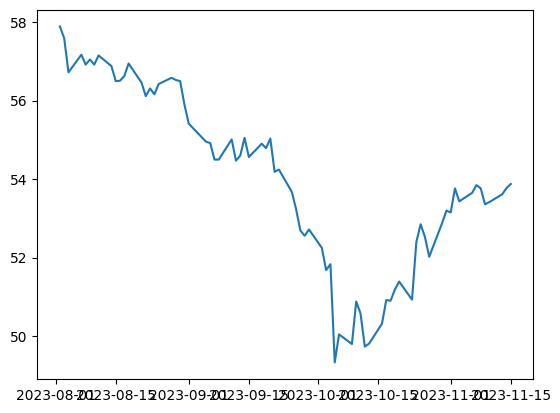

DataFrame creado para MSFT


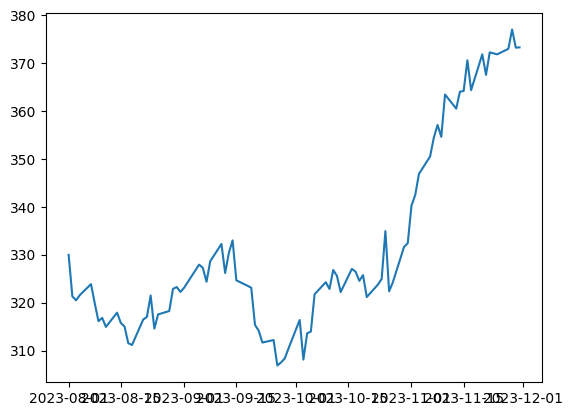

DataFrame creado para NVDA


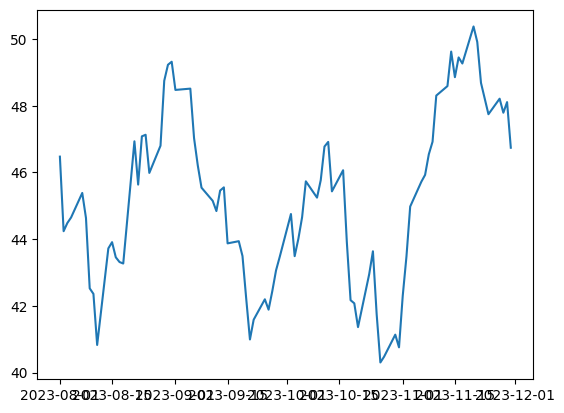

DataFrame creado para SPY


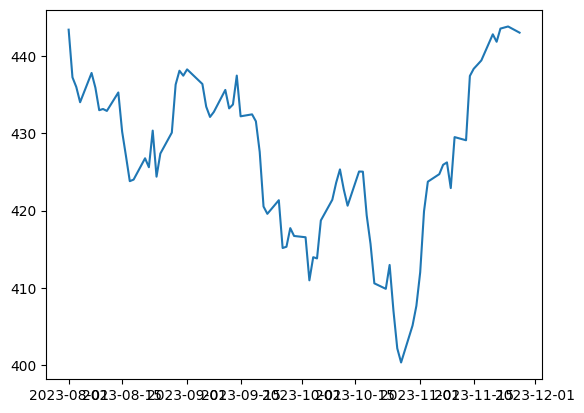

DataFrame creado para TSLA


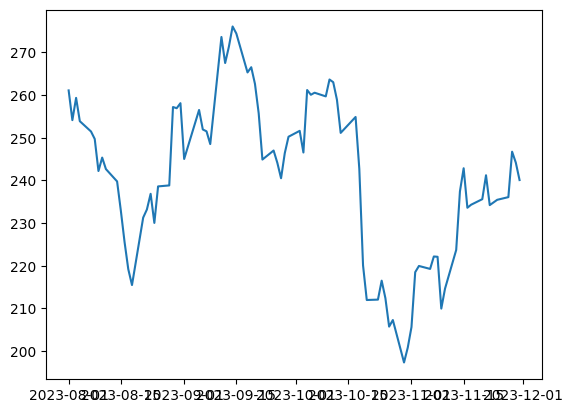

DataFrame creado para UBER


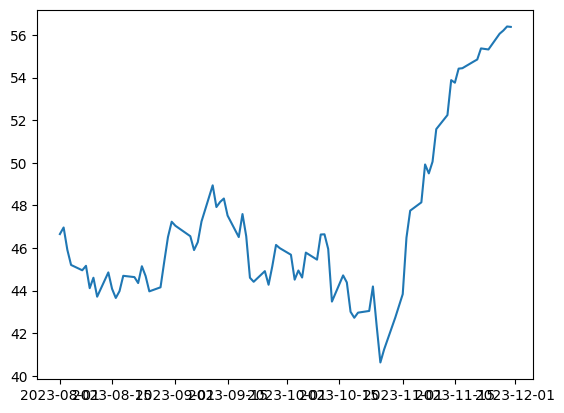

DataFrame creado para WMT


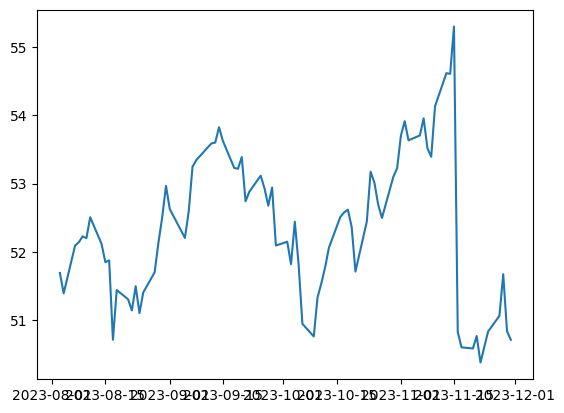

DataFrame creado para BRK-B


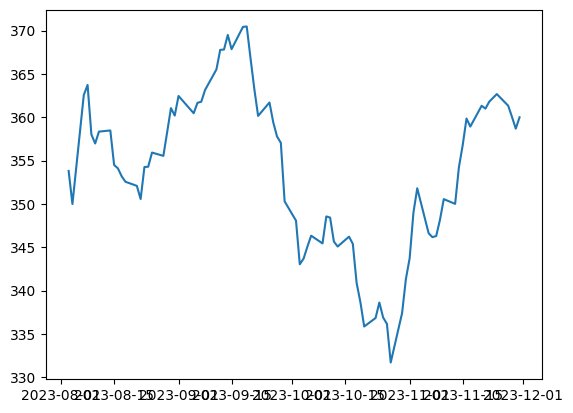

In [9]:
for ticker in dfs_por_ticker.keys():
    raw_sentiment= create_dataset_ticker(ticker, dfs_por_ticker)
    print(f"DataFrame creado para {ticker}")
    plt.plot(raw_sentiment['Date'], raw_sentiment['Adj Close'])
    plt.show()